In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
DATA_FOLDER = Path(".")

In [3]:
file_names = {
    "Credit Card Fraud":
        "credit_card_fraud_cleaned.csv",

    "Financial Fraud":
        "financial_fraud_cleaned.csv",

    "Fraud Detection":
        "fraud_detection_cleaned.csv",

    "Synthetic Fraud":
        "synthetic_fraud_cleaned.csv"
}

datasets = {}

for dataset_name, file_name in file_names.items():

    file_path = DATA_FOLDER / file_name

    if not file_path.exists():
        raise FileNotFoundError(
            f"File not found: {file_path}"
        )

    datasets[dataset_name] = pd.read_csv(file_path)

    print(
        dataset_name,
        "loaded:",
        datasets[dataset_name].shape
    )

Credit Card Fraud loaded: (11726, 18)
Financial Fraud loaded: (14654, 20)
Fraud Detection loaded: (11741, 19)
Synthetic Fraud loaded: (19540, 17)


In [4]:
for dataset_name in datasets:

    data = datasets[dataset_name].copy()

    data.columns = (
        data.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )

    datasets[dataset_name] = data

    print(
        "\n",
        dataset_name,
        "columns:"
    )

    print(data.columns.tolist())


 Credit Card Fraud columns:
['transaction_id', 'transaction_date', 'customer_id', 'card_type', 'amount', 'merchant_category', 'merchant_country', 'transaction_channel', 'device_type', 'is_international', 'is_card_present', 'transactions_last_24h', 'average_amount_30d', 'risk_score', 'is_fraud', 'transaction_hour', 'transaction_day', 'transaction_month']

 Financial Fraud columns:
['transaction_id', 'transaction_date', 'sender_account_id', 'receiver_account_id', 'transaction_type', 'amount', 'sender_balance_before', 'sender_balance_after', 'receiver_balance_before', 'receiver_balance_after', 'customer_age_group', 'customer_city', 'kyc_level', 'login_attempts', 'account_age_days', 'risk_score', 'is_fraud', 'transaction_hour', 'transaction_day', 'transaction_month']

 Fraud Detection columns:
['order_id', 'order_date', 'customer_id', 'product_category', 'order_amount', 'payment_method', 'billing_country', 'shipping_country', 'email_age_days', 'account_age_days', 'device_type', 'ip_risk_l

In [5]:
possible_target_columns = [
    "actual_fraud",
    "is_fraud",
    "fraud",
    "fraud_label",
    "label",
    "class",
    "target",
    "isfraud",
    "fraudulent"
]

target_columns = {}

for dataset_name, data in datasets.items():

    target_column = next(
        (
            column
            for column in possible_target_columns
            if column in data.columns
        ),
        None
    )

    if target_column is None:
        raise ValueError(
            f"Fraud label was not found in "
            f"{dataset_name}. Columns: "
            f"{data.columns.tolist()}"
        )

    target_columns[dataset_name] = target_column

    print(
        dataset_name,
        "target column:",
        target_column
    )

Credit Card Fraud target column: is_fraud
Financial Fraud target column: is_fraud
Fraud Detection target column: is_fraud
Synthetic Fraud target column: is_fraud


In [6]:
def convert_target_to_binary(target):
    
    cleaned_target = (
        target
        .astype(str)
        .str.strip()
        .str.lower()
    )

    target_mapping = {
        "0": 0,
        "1": 1,
        "false": 0,
        "true": 1,
        "no": 0,
        "yes": 1,
        "normal": 0,
        "genuine": 0,
        "legitimate": 0,
        "non_fraud": 0,
        "non-fraud": 0,
        "fraud": 1,
        "fraudulent": 1
    }

    converted_target = cleaned_target.map(
        target_mapping
    )

    return converted_target

prepared_datasets = {}

for dataset_name, data in datasets.items():

    data = data.copy()

    original_target = target_columns[dataset_name]

    data["actual_fraud"] = convert_target_to_binary(
        data[original_target]
    )

    data = data.dropna(
        subset=["actual_fraud"]
    ).copy()

    data["actual_fraud"] = (
        data["actual_fraud"].astype(int)
    )

    if original_target != "actual_fraud":
        data = data.drop(
            columns=[original_target]
        )

    prepared_datasets[dataset_name] = data

    print(f"\n{dataset_name}")
    print(data["actual_fraud"].value_counts())


Credit Card Fraud
actual_fraud
0    11604
1      122
Name: count, dtype: int64

Financial Fraud
actual_fraud
0    14469
1      185
Name: count, dtype: int64

Fraud Detection
actual_fraud
0    11383
1      358
Name: count, dtype: int64

Synthetic Fraud
actual_fraud
0    19207
1      333
Name: count, dtype: int64


In [7]:
feature_sets = []

for data in prepared_datasets.values():

    dataset_features = set(data.columns)

    dataset_features.discard("actual_fraud")

    feature_sets.append(dataset_features)

common_features = set.intersection(
    *feature_sets
)

columns_to_remove = {
    "transaction_id",
    "customer_id",
    "user_id",
    "account_id",
    "case_id",
    "dataset_source",
    "source_dataset",
    "index",
    "unnamed:_0",
    "risk_score"
}

common_features = sorted(
    common_features - columns_to_remove
)

print("Number of common features:", len(common_features))
print("Common features:")
print(common_features)

if len(common_features) == 0:
    raise ValueError(
        "The four datasets do not have common feature "
        "columns. Their columns must first be standardized."
    )

Number of common features: 3
Common features:
['transaction_day', 'transaction_hour', 'transaction_month']


In [8]:
reference_data = prepared_datasets[
    list(prepared_datasets.keys())[0]
]

numeric_features = [
    column
    for column in common_features
    if all(
        pd.api.types.is_numeric_dtype(
            data[column]
        )
        for data in prepared_datasets.values()
    )
]

categorical_features = [
    column
    for column in common_features
    if column not in numeric_features
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['transaction_day', 'transaction_hour', 'transaction_month']

Categorical features:
[]


In [9]:
def create_fraud_model():

    transformers = []

    if len(numeric_features) > 0:

        numeric_pipeline = Pipeline(
            steps=[
                (
                    "missing_values",
                    SimpleImputer(
                        strategy="median"
                    )
                ),
                (
                    "scaling",
                    StandardScaler()
                )
            ]
        )

        transformers.append(
            (
                "numeric",
                numeric_pipeline,
                numeric_features
            )
        )

    if len(categorical_features) > 0:

        categorical_pipeline = Pipeline(
            steps=[
                (
                    "missing_values",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),
                (
                    "encoding",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]
        )

        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers
    )

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        min_samples_split=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    complete_pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("model", model)
        ]
    )

    return complete_pipeline

In [10]:
cross_dataset_results = []
cross_dataset_predictions = []

for train_name, train_data in prepared_datasets.items():

    X_train = train_data[common_features].copy()
    y_train = train_data["actual_fraud"].copy()

    if y_train.nunique() < 2:
        print(
            f"Skipping {train_name}: "
            "training data contains only one class."
        )
        continue

    print(f"\nTraining on: {train_name}")

    fraud_model = create_fraud_model()

    fraud_model.fit(
        X_train,
        y_train
    )

    for test_name, test_data in prepared_datasets.items():

        if train_name == test_name:
            continue

        X_test = test_data[common_features].copy()
        y_test = test_data["actual_fraud"].copy()

        predictions = fraud_model.predict(X_test)

        probabilities = (
            fraud_model.predict_proba(X_test)[:, 1]
        )

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        precision = precision_score(
            y_test,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            predictions,
            zero_division=0
        )

        if y_test.nunique() == 2:
            roc_auc = roc_auc_score(
                y_test,
                probabilities
            )
        else:
            roc_auc = np.nan

        cross_dataset_results.append({
            "training_dataset": train_name,
            "testing_dataset": test_name,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "roc_auc": roc_auc
        })

        pair_predictions = pd.DataFrame({
            "training_dataset": train_name,
            "testing_dataset": test_name,
            "actual_fraud": y_test.to_numpy(),
            "predicted_fraud": predictions,
            "fraud_probability": probabilities
        })

        cross_dataset_predictions.append(
            pair_predictions
        )

        print(
            f"Tested on {test_name}: "
            f"F1 = {f1:.4f}, "
            f"AUC = {roc_auc:.4f}"
        )


Training on: Credit Card Fraud
Tested on Financial Fraud: F1 = 0.0106, AUC = 0.4418
Tested on Fraud Detection: F1 = 0.0190, AUC = 0.4838
Tested on Synthetic Fraud: F1 = 0.0236, AUC = 0.5145

Training on: Financial Fraud
Tested on Credit Card Fraud: F1 = 0.0117, AUC = 0.4611
Tested on Fraud Detection: F1 = 0.0346, AUC = 0.5279
Tested on Synthetic Fraud: F1 = 0.0368, AUC = 0.5166

Training on: Fraud Detection
Tested on Credit Card Fraud: F1 = 0.0063, AUC = 0.4933
Tested on Financial Fraud: F1 = 0.0295, AUC = 0.5144
Tested on Synthetic Fraud: F1 = 0.0339, AUC = 0.4984

Training on: Synthetic Fraud
Tested on Credit Card Fraud: F1 = 0.0261, AUC = 0.5099
Tested on Financial Fraud: F1 = 0.0277, AUC = 0.5056
Tested on Fraud Detection: F1 = 0.0418, AUC = 0.5137


In [11]:
cross_dataset_results = pd.DataFrame(
    cross_dataset_results
)

cross_dataset_results = (
    cross_dataset_results
    .sort_values(
        by="f1_score",
        ascending=False
    )
    .reset_index(drop=True)
)

cross_dataset_results.round(4)

,training_dataset,testing_dataset,accuracy,precision,recall,f1_score,roc_auc
0,Synthetic Fraud,Fraud Detection,0.9375,0.0392,0.0447,0.0418,0.5137
1,Financial Fraud,Synthetic Fraud,0.9651,0.0348,0.0390,0.0368,0.5166
2,Financial Fraud,Fraud Detection,0.9525,0.0455,0.0279,0.0346,0.5279
3,Fraud Detection,Synthetic Fraud,0.9446,0.0241,0.0571,0.0339,0.4984
4,Fraud Detection,Financial Fraud,0.9506,0.0196,0.0595,0.0295,0.5144
5,Synthetic Fraud,Financial Fraud,0.9569,0.0194,0.0486,0.0277,0.5056
6,Synthetic Fraud,Credit Card Fraud,0.9554,0.0169,0.0574,0.0261,0.5099
7,Credit Card Fraud,Synthetic Fraud,0.9704,0.0269,0.0210,0.0236,0.5145
8,Credit Card Fraud,Fraud Detection,0.9561,0.0299,0.0140,0.0190,0.4838
9,Financial Fraud,Credit Card Fraud,0.9713,0.0091,0.0164,0.0117,0.4611


In [12]:
average_performance = (
    cross_dataset_results
    .groupby("training_dataset")
    .agg(
        average_accuracy=("accuracy", "mean"),
        average_precision=("precision", "mean"),
        average_recall=("recall", "mean"),
        average_f1=("f1_score", "mean"),
        average_roc_auc=("roc_auc", "mean")
    )
    .sort_values(
        by="average_f1",
        ascending=False
    )
    .reset_index()
)

average_performance.round(4)

,training_dataset,average_accuracy,average_precision,average_recall,average_f1,average_roc_auc
0,Synthetic Fraud,0.9499,0.0252,0.0502,0.0319,0.5097
1,Financial Fraud,0.9630,0.0298,0.0278,0.0277,0.5018
2,Fraud Detection,0.9472,0.0159,0.0443,0.0232,0.5020
3,Credit Card Fraud,0.9670,0.0224,0.0153,0.0178,0.4800


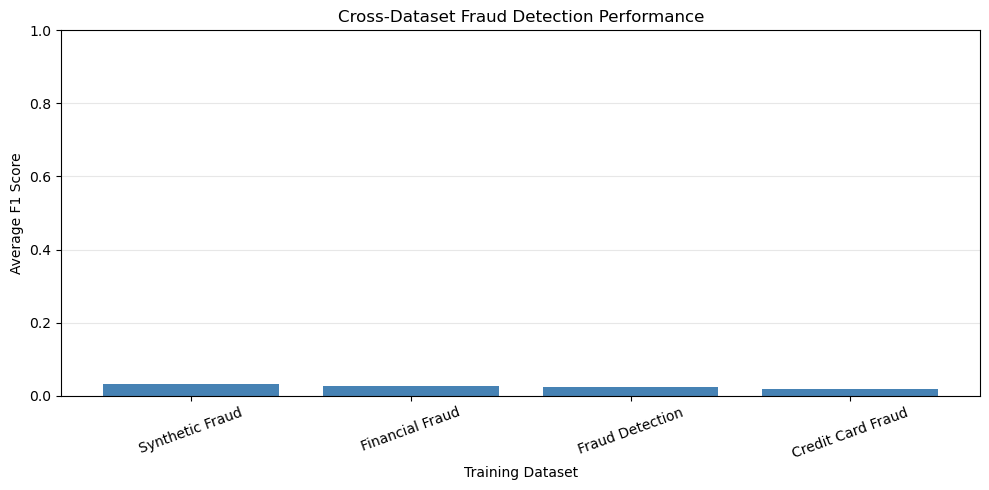

In [13]:
plt.figure(figsize=(10, 5))

plt.bar(
    average_performance["training_dataset"],
    average_performance["average_f1"],
    color="steelblue"
)

plt.title(
    "Cross-Dataset Fraud Detection Performance"
)
plt.xlabel("Training Dataset")
plt.ylabel("Average F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.tight_layout()
plt.show()

In [14]:
performance_matrix = (
    cross_dataset_results
    .pivot(
        index="training_dataset",
        columns="testing_dataset",
        values="f1_score"
    )
)

performance_matrix.round(4)

testing_dataset,Credit Card Fraud,Financial Fraud,Fraud Detection,Synthetic Fraud
training_dataset,,,,
Credit Card Fraud,NaN,0.0106,0.0190,0.0236
Financial Fraud,0.0117,NaN,0.0346,0.0368
Fraud Detection,0.0063,0.0295,NaN,0.0339
Synthetic Fraud,0.0261,0.0277,0.0418,NaN


In [15]:
all_predictions = pd.concat(
    cross_dataset_predictions,
    ignore_index=True
)

cross_dataset_results.to_csv(
    "cross_dataset_validation_results.csv",
    index=False
)

average_performance.to_csv(
    "cross_dataset_average_performance.csv",
    index=False
)

all_predictions.to_csv(
    "cross_dataset_predictions.csv",
    index=False
)

performance_matrix.to_csv(
    "cross_dataset_f1_matrix.csv"
)

print("Files saved successfully:")
print("1. cross_dataset_validation_results.csv")
print("2. cross_dataset_average_performance.csv")
print("3. cross_dataset_predictions.csv")
print("4. cross_dataset_f1_matrix.csv")

Files saved successfully:
1. cross_dataset_validation_results.csv
2. cross_dataset_average_performance.csv
3. cross_dataset_predictions.csv
4. cross_dataset_f1_matrix.csv
